In [1]:
# PASO 1: Importamos las librerías necesarias

# Librerías con Pandas::
import pandas as pd # Para trabajar con DataFrames *
import numpy as np # Para trabajar con arrays y funciones matemáticas

# Librerías para visualización de datos:
import matplotlib.pyplot as plt # Para crear gráficos personalizados
import seaborn as sns # Para crear gráficos más atractivos y con menos código 

# Configuraciones:
import warnings # Para controlar las advertencias
warnings.filterwarnings('ignore', category = FutureWarning) # Para ignorar las advertencias de tipo FutureWarning
pd.set_option('display.max_columns', None) # Para mostrar todas las columnas del DataFrame *

In [45]:
# PASO 2: Cargamos el dataset ya limpio 

df_limpio = pd.read_csv("combinado_limpio.csv")

df_limpio.head()

,Loyalty Number,Year,Month,Flights Booked,Flights with Companions,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month
0,100018,2017,1,3,0,3,1521.0,152.0,0.0,0.0,Canada,Alberta,Edmonton,T9G 1W3,Female,Bachelor,92552.0,Married,Aurora,7919.20,Standard,2016,8,Desconocido,Desconocido
1,100102,2017,1,10,4,14,2030.0,203.0,0.0,0.0,Canada,Ontario,Toronto,M1R 4K3,Male,College,73447.0,Single,Nova,2887.74,Standard,2013,3,Desconocido,Desconocido
2,100140,2017,1,6,0,6,1200.0,120.0,0.0,0.0,Canada,British Columbia,Dawson Creek,U5I 4F1,Female,College,73447.0,Divorced,Nova,2838.07,Standard,2016,7,Desconocido,Desconocido
3,100214,2017,1,0,0,0,0.0,0.0,0.0,0.0,Canada,British Columbia,Vancouver,V5R 1W3,Male,Bachelor,63253.0,Married,Star,4170.57,Standard,2015,8,Desconocido,Desconocido
4,100272,2017,1,0,0,0,0.0,0.0,0.0,0.0,Canada,Ontario,Toronto,P1L 8X8,Female,Bachelor,91163.0,Divorced,Star,6622.05,Standard,2014,1,Desconocido,Desconocido


PREGUNTA 1: *¿Cómo se distribuye la cantidad de vuelos reservados por mes durante el año?*

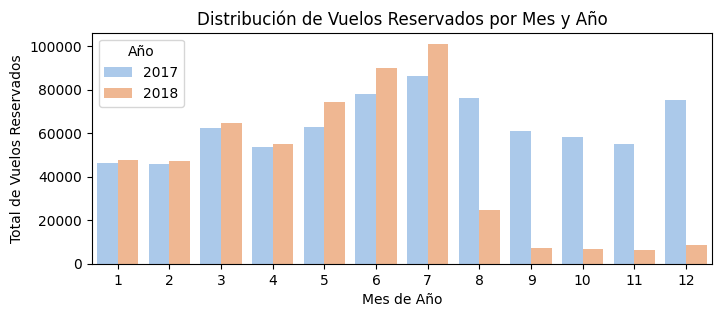

In [49]:
plt.figure(figsize=(8, 3))
sns.barplot(data=df_limpio, x="Month", y= "Flights Booked", hue="Year", estimator="sum", palette="pastel", errorbar=None); # Suma = cantidad total
plt.title("Distribución de Vuelos Reservados por Mes y Año") 
plt.xlabel("Mes de Año")
plt.ylabel("Total de Vuelos Reservados")
plt.legend(title="Año")
plt.show()

- Descripción: La gráfica representa el total de vuelos reservados en cada mes del año, diferenciados por año. Esto permite observar si existen meses con mayor concentración de reservas de vuelos y comparar la evolución de la actividad entre distintos años
    - En el año 2017 y 2018 el mes que tuvo más reservas fue el 7 (julio)
    - En eñ año 2017 el mes con menos reservas aparentemente por igual fueron el 1 (enero) y 2 (febrero), en cambio, en el 2018 fue el mes 11 (noviembre)

PREGUNTA 2: *¿Existe una relación entre la distancia de los vuelos y los puntos acumulados por los clientes?*

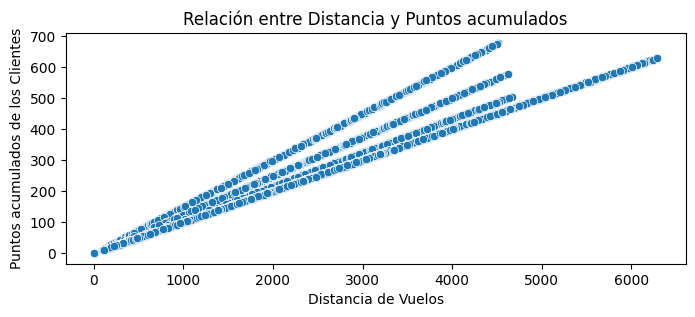

In [15]:
plt.figure(figsize=(8, 3))
sns.scatterplot(data=df_limpio, x="Distance", y="Points Accumulated");
plt.title("Relación entre Distancia y Puntos acumulados")
plt.xlabel("Distancia de Vuelos")
plt.ylabel("Puntos acumulados de los Clientes")
plt.show()

- Descripción: La gráfica representa la relación entre la distancia recorrida en los vuelos y los puntos acumulados por los clientes. Cada punto corresponde a una observación del dataset (fila). Esto permite observar que si existe una relación entre ambas variables y, además, con una tendencia positiva porque a mayor distancia del vuelo, mayor número de puntos acumulados tiene los clientes

PREGUNTA 3: *¿Cuál es la distribución de los clientes por provincia o estado?*

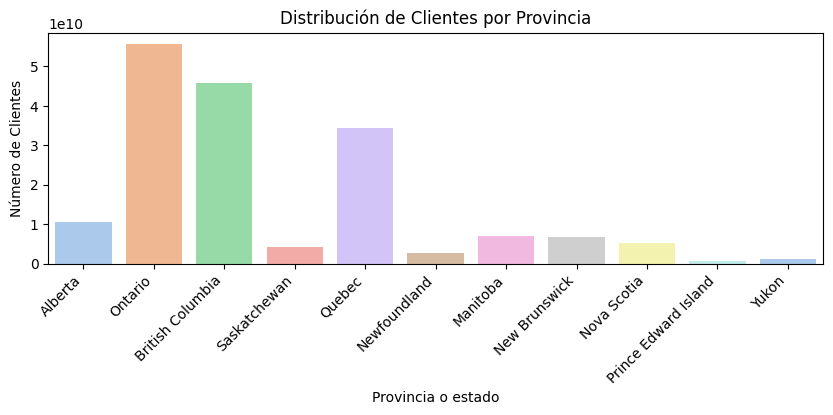

In [72]:
plt.figure(figsize=(10, 3))
sns.barplot(data=df_limpio, x="Province", y="Loyalty Number", palette="pastel", estimator="sum", errorbar=None); # Suma = cantidad total
plt.title("Distribución de Clientes por Provincia")
plt.xlabel("Provincia o estado")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Número de Clientes")
plt.show()

- Descripción: La gráfica representa el número total de clientes por provincia o estado. Esto permite observar en qué zonas se concentra una mayor parte de los clientes y comparar la distribución geográfica
    - En Ontario es dónde hay más clientes pertenecientes, seguido de British Columbia y Quebec
    - La provincia o estado con menos clientes es Prince Edward Island


PREGUNTA 4: *¿Cómo se compara el salario promedio entre los diferentes niveles educativos de los clientes?*

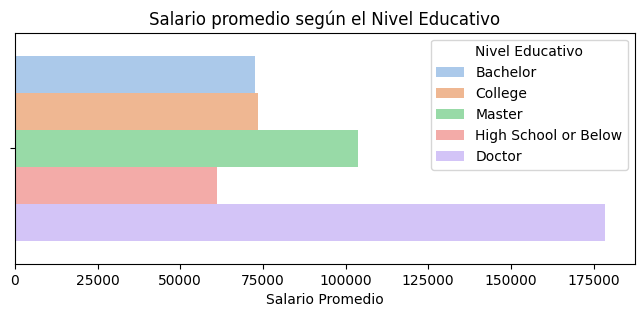

In [ ]:
plt.figure(figsize=(8, 3))
sns.barplot(data=df_limpio, x="Salary", hue="Education", palette="pastel", errorbar=None); 
plt.title("Salario promedio según el Nivel Educativo")
plt.xlabel("Salario Promedio")
plt.legend(title="Nivel Educativo")
plt.show()

- Descripción: La gráfica representa el salario promedio de los clientes en función de su nivel educativo. Esto permite observar las diferencias salariales entre los distintos grupos
    - Aquellos clientes que han hecho un doctorado o un máster, ganan más dinero
    - Aquellos que están en bachillerato o en la unioversidad ganan prácticamente igual

PREGUNTA 5: *¿Cuál es la proporción de clientes con diferentes tipos de tarjetas de fidelidad?*

In [ ]:
tipos_tarjetas = df_limpio["Loyalty Card"].value_counts()

tipos_tarjetas

Loyalty Card
Star      14700800
Nova      10938900
Aurora     6635800
Name: count, dtype: int64

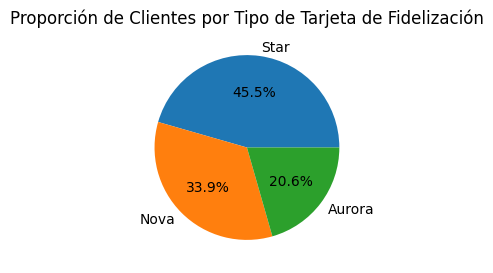

In [65]:
plt.figure(figsize=(8, 3))
plt.pie(x=tipos_tarjetas, labels=tipos_tarjetas.index, autopct="%1.1f%%") # .index = Sacar el nombre + autopct="%1.1f%%" = Muestra el porcentaje
plt.title("Proporción de Clientes por Tipo de Tarjeta de Fidelización")
plt.show()

- Descripción: La gráfica representa la proporción de clientes según el tipo de tarjeta de fidelidad. Esto permite observar el porcentaje de cada tipo de tarjeta en base a los datos de los clientes y comparar entre ellos
    - La Tarjeta Star tiene el mayor número de clientes

PREGUNTA 6: *¿Cómo se distribuyen los clientes según su estado civil y género?*

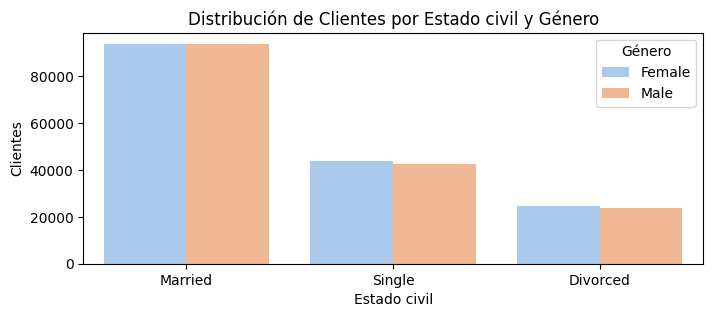

In [ ]:
plt.figure(figsize=(8, 3))
sns.countplot(data=df_limpio, x="Marital Status", hue="Gender", palette="pastel");
plt.title("Distribución de Clientes por Estado civil y Género")
plt.xlabel("Estado civil")
plt.ylabel("Número de Clientes")
plt.legend(title="Género")
plt.show()

- Descripción: La gráfica representa el número total de clientes según su estado civil y género. Esto permite observar la distribución conjunta de ambas variables y comparar entre ellos
    - La cantidad de clientes que están casados es independient eal sexo (mujer y hombre)
    - Tanto en los divorciados ocmo en los solteros existe una mínima diferencia según el sexo, hay una cantidad mayor en las mujeres que en los hombres